<a href="https://colab.research.google.com/github/chanu-24/BMW-CAR-COMPUTER-VISION/blob/main/DAY4(Bunding__BOX).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 [Day 4] 번호판 타겟팅 재도전! (Dilation 장착)

📸 1. 선을 뚱뚱하게 불린 윤곽선 (Dilation)


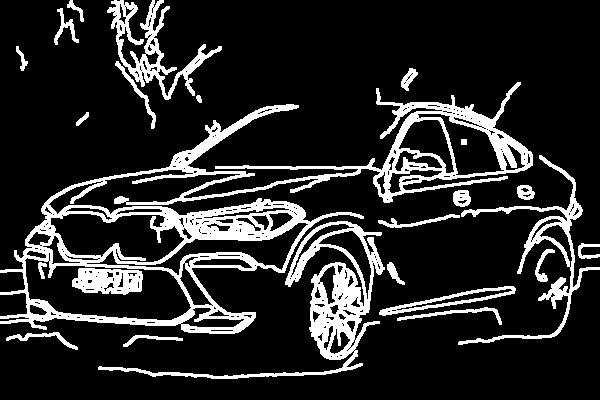


🎯 2. 재도전 타겟팅 완료!


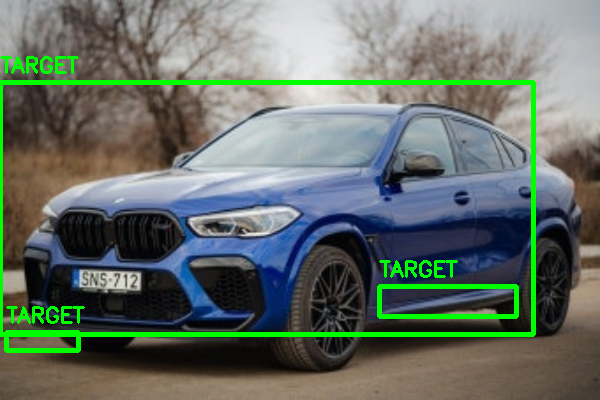

In [9]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

print("🚀 [Day 4] 번호판 타겟팅 재도전! (Dilation 장착)")

file_name = 'my_bmw.jpg'
img = cv2.imread(file_name)

if img is None:
    print("❌ 사진을 다시 업로드해주세요!")
else:
    img = cv2.resize(img, (600, 400))
    draw_img = img.copy()

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)

    # ----------------------------------------------------
    # 💡 [마법의 주문] 얇은 선을 뚱뚱하게 만들어서 끊어진 틈 메우기!
    # ----------------------------------------------------
    kernel = np.ones((3, 3), np.uint8)
    thick_edges = cv2.dilate(edges, kernel, iterations=1) # 선 팽창!

    # 팽창된 두꺼운 선(thick_edges)에서 도형을 찾습니다.
    contours, _ = cv2.findContours(thick_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 조건 필터링
    for cnt in contours:
        if cv2.contourArea(cnt) < 200:
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(w) / h

        # 비율 2.0 ~ 5.0 사이의 길쭉한 네모 찾기
        if 2.0 <= aspect_ratio <= 5.0:
            cv2.rectangle(draw_img, (x, y), (x+w, y+h), (0, 255, 0), 3)
            cv2.putText(draw_img, "TARGET", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    print("\n📸 1. 선을 뚱뚱하게 불린 윤곽선 (Dilation)")
    cv2_imshow(thick_edges)

    print("\n🎯 2. 재도전 타겟팅 완료!")
    cv2_imshow(draw_img)










*하얀색 뼈대들을 하나로 이어붙여서 우리가 원하는 물체의 모양을 정확히 찾아 네모난 상자를 치는법을 마스터하는것

주차장 차단기나 과속단속 카메라에 들어가는 '번호판 인식 시스템'의 심장!


2일차에 canny 엣지로 뽑아낸 선들은 사실 컴퓨터 입장에선 그저 '하얀색
점들의 모임'

이 점들을 선긋기 하듯 쭉 이어 붙여서 하나의 닫힌 도형으로
만드는 기술을 등고선이라고 한다.

1.외곽선 찾기(findContours):뼈대들을 이어 붙여서 여러개의 폴리곤 조각을 만든다.

2.조건 필터링:수많은 조각중 번호판을 찾으려면?
"가로가 세로보다 약 2~3배 정도 길고,면적이 너무 작지않은 네모조각만 찾아!라고 조건을 걸어준다.

3.바운딩 박스(boundingRect):조건에 맞는 조각을 찾았다면, 그 조각을 덮어버리는 반듯한 초록색 상자를 친다.

결과-> 실패

창문이나 라디에이터 그릴에 여러개의 상자가 쳐질수도 있다.
이를 극복하기 위해 천재들이 만든 PYTORCH와 CNN

ㅈ



